In [2]:
import numpy as np
import librosa
import subprocess
import tempfile
import soundfile as sf
from scipy.signal import find_peaks
from scipy import fft, signal

import IPython.display as ipd

In [3]:
audio_file = "/data/amey_2311cs10/debayan/test_mentalhealth_16kHz/_pkXuC7vsl0_chunk9_data2_task2.wav"
ipd.Audio(audio_file)

In [5]:
y, sr = librosa.load(audio_file, sr=16000)
print(y.shape)
print(sr)
y

(233841,)
16000


array([0.00167847, 0.00408936, 0.0144043 , ..., 0.01254272, 0.01358032,
       0.        ], dtype=float32)

# Pitch Variability, Speech rate, Pause Frequency

In [5]:
def calculate_pitch_variability(audio_path):
    # standard deviation of the fundamental frequency (F0) — a measure of how much the pitch varies over time
    """Calculate pitch variability (standard deviation of fundamental frequency) using Librosa"""
    try:
        y, sr = librosa.load(audio_path, sr=None)
        pitches, magnitudes = librosa.piptrack(y=y, sr=sr, fmin=75, fmax=400)
        pitches = pitches[pitches > 0]  # Remove invalid pitches
        return np.std(pitches) if len(pitches) > 0 else 0.0
    except Exception as e:
        print(f"Error in pitch calculation: {e}")
        return 0.0

In [14]:
print(f"Pitch Variability ie standard deviation of the fundamental frequency (F0) : {calculate_speech_rate(audio_file):.2f} ")

Pitch Variability ie standard deviation of the fundamental frequency (F0) : 1.44 


In [10]:
def calculate_speech_rate(audio_path, sr=16000, frame_length=2048, hop_length=512):
    """Estimate speech rate using energy peak detection"""
    # Load audio
    y, sr = librosa.load(audio_path, sr=sr)
    
    # Calculate RMS energy
    rms = librosa.feature.rms(y=y, frame_length=frame_length, hop_length=hop_length)[0]
    
    # Smooth with moving average
    window_size = 5
    rms_smooth = np.convolve(rms, np.ones(window_size)/window_size, mode='same')
    
    # Detect peaks (syllable nuclei candidates)
    peaks, _ = find_peaks(rms_smooth, height=np.median(rms_smooth)*1.2, distance=5)
    
    # Calculate speaking duration (exclude silence)
    silence_threshold = 0.02 * np.max(rms)
    speech_frames = np.sum(rms > silence_threshold)
    speaking_duration = (speech_frames * hop_length) / sr
    
    # Avoid division by zero
    if speaking_duration == 0:
        return 0.0
    
    # Syllables per second (speech rate)
    return len(peaks) / speaking_duration

In [15]:
print(f"Estimated speech rate: {calculate_speech_rate(audio_file):.2f} syllables/sec")

Estimated speech rate: 1.44 syllables/sec


In [3]:
def calculate_pause_frequency(audio_path, silence_threshold=-30, min_pause_duration=0.1):
    """Calculate pause frequency (pauses/second) using Librosa"""
    try:
        y, sr = librosa.load(audio_path, sr=None)
        frame_length = int(0.025 * sr)  # 25ms frames
        hop_length = int(0.010 * sr)    # 10ms hop (overlap)

        rms = librosa.feature.rms(y=y, frame_length=frame_length, hop_length=hop_length)[0]
        db = librosa.amplitude_to_db(rms, ref=np.max)

        silence_mask = db < silence_threshold
        silence_changes = np.diff(silence_mask.astype(int))

        pause_starts = np.where(silence_changes == 1)[0]
        pause_ends = np.where(silence_changes == -1)[0]

        # Edge case correction
        if pause_ends.size > 0 and pause_starts.size > 0:
            if pause_ends[0] < pause_starts[0]:
                pause_ends = pause_ends[1:]
            if pause_starts.size > pause_ends.size:
                pause_starts = pause_starts[:-1]

        pause_durations = [(end - start) * hop_length / sr
                           for start, end in zip(pause_starts, pause_ends)
                           if (end - start) * hop_length / sr >= min_pause_duration]

        total_duration = librosa.get_duration(y=y, sr=sr)
        return len(pause_durations) / total_duration if total_duration > 0 else 0.0

    except Exception as e:
        print(f"Error in pause calculation: {e}")
        return 0.0

In [37]:
print(f"Pause Frequency: {calculate_pause_frequency(audio_file):.2f}")

Pause Frequency: 0.00


In [34]:
def calculate_pause_frequency(audio_path, silence_threshold=-30, min_pause_duration=0.1, plot=False):
    """Calculate pause frequency (pauses/second) using Librosa"""
    try:
        y, sr = librosa.load(audio_path, sr=None)
        frame_length = int(0.025 * sr)  # 25ms
        hop_length = int(0.010 * sr)    # 10ms hop

        # Compute RMS and convert to dB
        rms = librosa.feature.rms(y=y, frame_length=frame_length, hop_length=hop_length)[0]
        db = librosa.amplitude_to_db(rms, ref=np.max)

        # Detect silence
        silence_mask = db < silence_threshold
        changes = np.diff(silence_mask.astype(int))

        pause_starts = np.where(changes == 1)[0]
        pause_ends = np.where(changes == -1)[0]

        # Handle edge cases
        if len(pause_ends) > 0 and len(pause_starts) > 0:
            if pause_ends[0] < pause_starts[0]:
                pause_ends = pause_ends[1:]
            if len(pause_starts) > len(pause_ends):
                pause_starts = pause_starts[:-1]

        # Pause durations
        pause_durations = [(end - start) * hop_length / sr
                           for start, end in zip(pause_starts, pause_ends)
                           if (end - start) * hop_length / sr >= min_pause_duration]

        # Total duration
        total_duration = librosa.get_duration(y=y, sr=sr)
        pause_freq = len(pause_durations) / total_duration if total_duration > 0 else 0.0

        if plot:
            # Plotting the dB over time and silence threshold
            times = librosa.frames_to_time(np.arange(len(db)), sr=sr, hop_length=hop_length)
            plt.figure(figsize=(12, 4))
            plt.plot(times, db, label='RMS (dB)')
            plt.axhline(y=silence_threshold, color='r', linestyle='--', label='Silence threshold')
            plt.fill_between(times, db, silence_threshold, where=(db < silence_threshold), color='gray', alpha=0.4)
            plt.title('RMS Energy with Silence Detection')
            plt.xlabel('Time (s)')
            plt.ylabel('dB')
            plt.legend()
            plt.tight_layout()
            plt.show()

        return pause_freq

    except Exception as e:
        print(f"Error in pause calculation: {e}")
        return 0.0


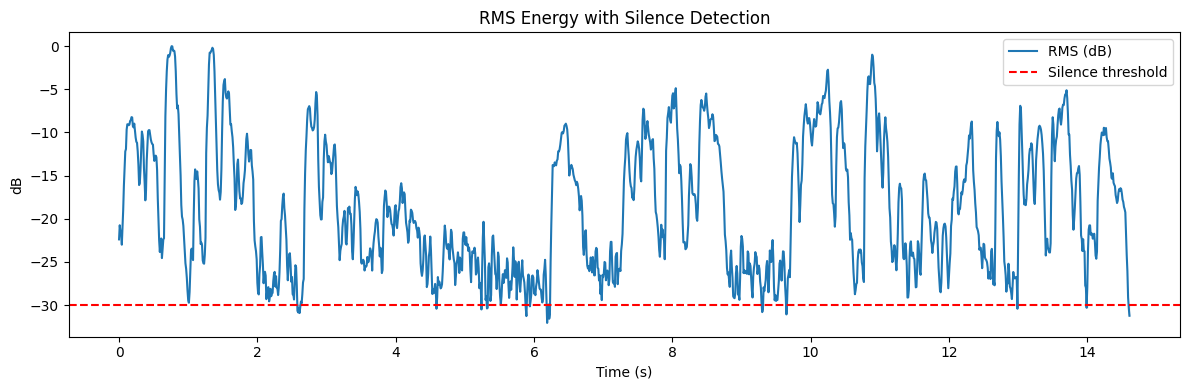

Pause Frequency: 0.0


In [35]:
pf = calculate_pause_frequency(audio_file, plot=True)
print("Pause Frequency:", round(pf, 2))

# MFCC

In [57]:
def mfcc_tool(audio_path: str, n_mfcc: int = 13, hop_length: int = 512) -> np.ndarray:
    """MFCC feature extraction tool for speech analysis"""
    try:
        y, sr = librosa.load(audio_path, sr=None)
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc, hop_length=hop_length)
        return mfccs.T  # Return time-major features
    except Exception as e:
        print(f"MFCC Error: {e}")
        return np.array([])

In [58]:
mfcc = mfcc_tool(audio_file)
mfcc, mfcc.shape

(array([[-2.00639877e+02,  3.69435959e+01, -1.67711525e+01, ...,
          6.61450911e+00,  1.10315771e+01, -6.06349182e+00],
        [-1.72266724e+02,  6.93900299e+01, -7.39591885e+00, ...,
         -1.08029842e-02,  1.25370846e+01, -4.07270193e+00],
        [-1.49231934e+02,  1.21187744e+02, -2.49447441e+01, ...,
         -8.98757100e-01,  1.41605740e+01,  1.08071816e+00],
        ...,
        [-2.90266235e+02,  1.16563522e+02,  4.21083145e+01, ...,
         -5.47659206e+00, -2.10520792e+00, -6.19770288e+00],
        [-2.97917847e+02,  1.06653229e+02,  4.27362976e+01, ...,
         -4.41315556e+00, -2.69464707e+00, -8.14207268e+00],
        [-3.11968750e+02,  9.59448471e+01,  4.15282288e+01, ...,
         -3.46383238e+00, -5.21207380e+00, -9.40369225e+00]], dtype=float32),
 (457, 13))

In [59]:
# Code to visualize MFCC

import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats

def visualize_mfcc_mental_health(audio_path, n_mfcc=13, sr=22050):
    """
    Comprehensive MFCC visualization for mental health analysis
    """
    # Load audio file
    y, sr = librosa.load(audio_path, sr=sr)
    
    # Extract MFCC features
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    
    # Calculate delta and delta-delta coefficients (important for depression detection)
    delta_mfccs = librosa.feature.delta(mfccs)
    delta2_mfccs = librosa.feature.delta(mfccs, order=2)
    
    # Create comprehensive visualization
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('MFCC Analysis for Mental Health Assessment', fontsize=16)
    
    # 1. MFCC Heatmap
    librosa.display.specshow(mfccs, x_axis='time', ax=axes[0,0], cmap='viridis')
    axes[0,0].set_title('MFCC Coefficients')
    axes[0,0].set_ylabel('MFCC Coefficients')
    
    # 2. Delta MFCC (temporal changes)
    librosa.display.specshow(delta_mfccs, x_axis='time', ax=axes[0,1], cmap='RdBu_r')
    axes[0,1].set_title('Delta MFCC (1st Derivative)')
    axes[0,1].set_ylabel('Delta MFCC')
    
    # 3. Delta-Delta MFCC (acceleration)
    librosa.display.specshow(delta2_mfccs, x_axis='time', ax=axes[0,2], cmap='RdBu_r')
    axes[0,2].set_title('Delta-Delta MFCC (2nd Derivative)')
    axes[0,2].set_ylabel('Delta-Delta MFCC')
    
    # 4. MFCC2 Analysis (critical for depression detection)
    mfcc2_values = mfccs[1, :]  # MFCC coefficient 2 (important for depression)
    axes[1,0].plot(mfcc2_values, color='red', linewidth=2)
    axes[1,0].set_title('MFCC2 Over Time (Depression Biomarker)')
    axes[1,0].set_xlabel('Time Frames')
    axes[1,0].set_ylabel('MFCC2 Value')
    axes[1,0].grid(True, alpha=0.3)
    
    # Add threshold lines for depression indication
    mean_mfcc2 = np.mean(mfcc2_values)
    axes[1,0].axhline(y=mean_mfcc2, color='blue', linestyle='--', 
                      label=f'Mean: {mean_mfcc2:.2f}')
    axes[1,0].legend()
    
    # 5. Spectral Energy Distribution (2000-3000Hz range analysis)
    spectral_analysis = np.mean(mfccs, axis=1)
    axes[1,1].bar(range(len(spectral_analysis)), spectral_analysis, color='purple', alpha=0.7)
    axes[1,1].set_title('Mean MFCC Coefficients Distribution')
    axes[1,1].set_xlabel('MFCC Coefficient Index')
    axes[1,1].set_ylabel('Mean Value')
    
    # Highlight MFCC2 (critical for depression)
    axes[1,1].bar(1, spectral_analysis[1], color='red', alpha=0.9, 
                  label='MFCC2 (Depression Indicator)')
    axes[1,1].legend()
    
    # 6. Variability Analysis (important for mental health)
    mfcc_std = np.std(mfccs, axis=1)
    axes[1,2].plot(mfcc_std, marker='o', color='green', linewidth=2, markersize=6)
    axes[1,2].set_title('MFCC Variability (Mental Health Indicator)')
    axes[1,2].set_xlabel('MFCC Coefficient Index')
    axes[1,2].set_ylabel('Standard Deviation')
    axes[1,2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return mfccs, delta_mfccs, delta2_mfccs


In [ ]:
# Code to visualize MFCC

import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats

def visualize_mfcc_mental_health(audio_path, n_mfcc=13, sr=22050):
    """
    Comprehensive MFCC visualization for mental health analysis
    """
    # Load audio file
    y, sr = librosa.load(audio_path, sr=sr)
    
    # Extract MFCC features
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    
    # Calculate delta and delta-delta coefficients (important for depression detection)
    delta_mfccs = librosa.feature.delta(mfccs)
    delta2_mfccs = librosa.feature.delta(mfccs, order=2)
    
    # Create comprehensive visualization
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('MFCC Analysis for Mental Health Assessment', fontsize=16)
    
    # 1. MFCC Heatmap
    librosa.display.specshow(mfccs, x_axis='time', ax=axes[0,0], cmap='viridis')
    axes[0,0].set_title('MFCC Coefficients')
    axes[0,0].set_ylabel('MFCC Coefficients')
    
    # 2. Delta MFCC (temporal changes)
    librosa.display.specshow(delta_mfccs, x_axis='time', ax=axes[0,1], cmap='RdBu_r')
    axes[0,1].set_title('Delta MFCC (1st Derivative)')
    axes[0,1].set_ylabel('Delta MFCC')
    
    # 3. Delta-Delta MFCC (acceleration)
    librosa.display.specshow(delta2_mfccs, x_axis='time', ax=axes[0,2], cmap='RdBu_r')
    axes[0,2].set_title('Delta-Delta MFCC (2nd Derivative)')
    axes[0,2].set_ylabel('Delta-Delta MFCC')
    
    # 4. MFCC2 Analysis (critical for depression detection)
    mfcc2_values = mfccs[1, :]  # MFCC coefficient 2 (important for depression)
    axes[1,0].plot(mfcc2_values, color='red', linewidth=2)
    axes[1,0].set_title('MFCC2 Over Time (Depression Biomarker)')
    axes[1,0].set_xlabel('Time Frames')
    axes[1,0].set_ylabel('MFCC2 Value')
    axes[1,0].grid(True, alpha=0.3)
    
    # Add threshold lines for depression indication
    mean_mfcc2 = np.mean(mfcc2_values)
    axes[1,0].axhline(y=mean_mfcc2, color='blue', linestyle='--', 
                      label=f'Mean: {mean_mfcc2:.2f}')
    axes[1,0].legend()
    
    # 5. Spectral Energy Distribution (2000-3000Hz range analysis)
    spectral_analysis = np.mean(mfccs, axis=1)
    axes[1,1].bar(range(len(spectral_analysis)), spectral_analysis, color='purple', alpha=0.7)
    axes[1,1].set_title('Mean MFCC Coefficients Distribution')
    axes[1,1].set_xlabel('MFCC Coefficient Index')
    axes[1,1].set_ylabel('Mean Value')
    
    # Highlight MFCC2 (critical for depression)
    axes[1,1].bar(1, spectral_analysis[1], color='red', alpha=0.9, 
                  label='MFCC2 (Depression Indicator)')
    axes[1,1].legend()
    
    # 6. Variability Analysis (important for mental health)
    mfcc_std = np.std(mfccs, axis=1)
    axes[1,2].plot(mfcc_std, marker='o', color='green', linewidth=2, markersize=6)
    axes[1,2].set_title('MFCC Variability (Mental Health Indicator)')
    axes[1,2].set_xlabel('MFCC Coefficient Index')
    axes[1,2].set_ylabel('Standard Deviation')
    axes[1,2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return mfccs, delta_mfccs, delta2_mfccs


In [60]:
def mental_health_mfcc_analysis(audio_path):
    """
    Specific analysis for mental health indicators in MFCC features
    """
    y, sr = librosa.load(audio_path, sr=22050)
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
    
    # Key mental health indicators
    mfcc2_mean = np.mean(mfccs[1, :])  # MFCC2 for depression detection
    mfcc_variability = np.mean(np.std(mfccs, axis=1))  # Overall variability
    
    # Calculate energy in 2000-3000Hz range (represented by MFCC2)
    energy_drop = mfcc2_mean < -2.0  # Threshold for depression indication
    
    # Create interpretation visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # MFCC2 time series with depression threshold
    ax1.plot(mfccs[1, :], color='darkred', linewidth=2, label='MFCC2 Values')
    ax1.axhline(y=-2.0, color='orange', linestyle='--', linewidth=2, 
                label='Depression Threshold')
    ax1.axhline(y=mfcc2_mean, color='blue', linestyle='-', linewidth=2, 
                label=f'Mean: {mfcc2_mean:.2f}')
    ax1.set_title('MFCC2 Depression Analysis')
    ax1.set_xlabel('Time Frames')
    ax1.set_ylabel('MFCC2 Value')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Mental health risk assessment
    colors = ['red' if energy_drop else 'green']
    labels = ['High Risk' if energy_drop else 'Low Risk']
    
    ax2.bar(['Depression Risk'], [abs(mfcc2_mean)], color=colors[0], alpha=0.7)
    ax2.set_title('Mental Health Risk Assessment')
    ax2.set_ylabel('Risk Level (|MFCC2 Mean|)')
    ax2.text(0, abs(mfcc2_mean)/2, labels[0], ha='center', fontsize=12, 
             color='white', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Print analysis results
    print("\n=== Mental Health MFCC Analysis ===")
    print(f"MFCC2 Mean Value: {mfcc2_mean:.3f}")
    print(f"Overall MFCC Variability: {mfcc_variability:.3f}")
    print(f"Depression Risk Indicator: {'HIGH' if energy_drop else 'LOW'}")
    print(f"Interpretation: {'Reduced energy in 2000-3000Hz range detected' if energy_drop else 'Normal spectral energy distribution'}")
    
    return mfcc2_mean, mfcc_variability, energy_drop

In [ ]:
if __name__ == "__main__":
    audio_file = "/data/amey_2311cs10//debayan/test_mentalhealth_16kHz/_pkXuC7vsl0_chunk9_data2_task2.wav"
    # Basic MFCC visualization
    mfccs, delta_mfccs, delta2_mfccs = visualize_mfcc_mental_health(audio_file)
    # Mental health analysis
    mfcc2_mean, variability, risk = mental_health_mfcc_analysis(audio_file)

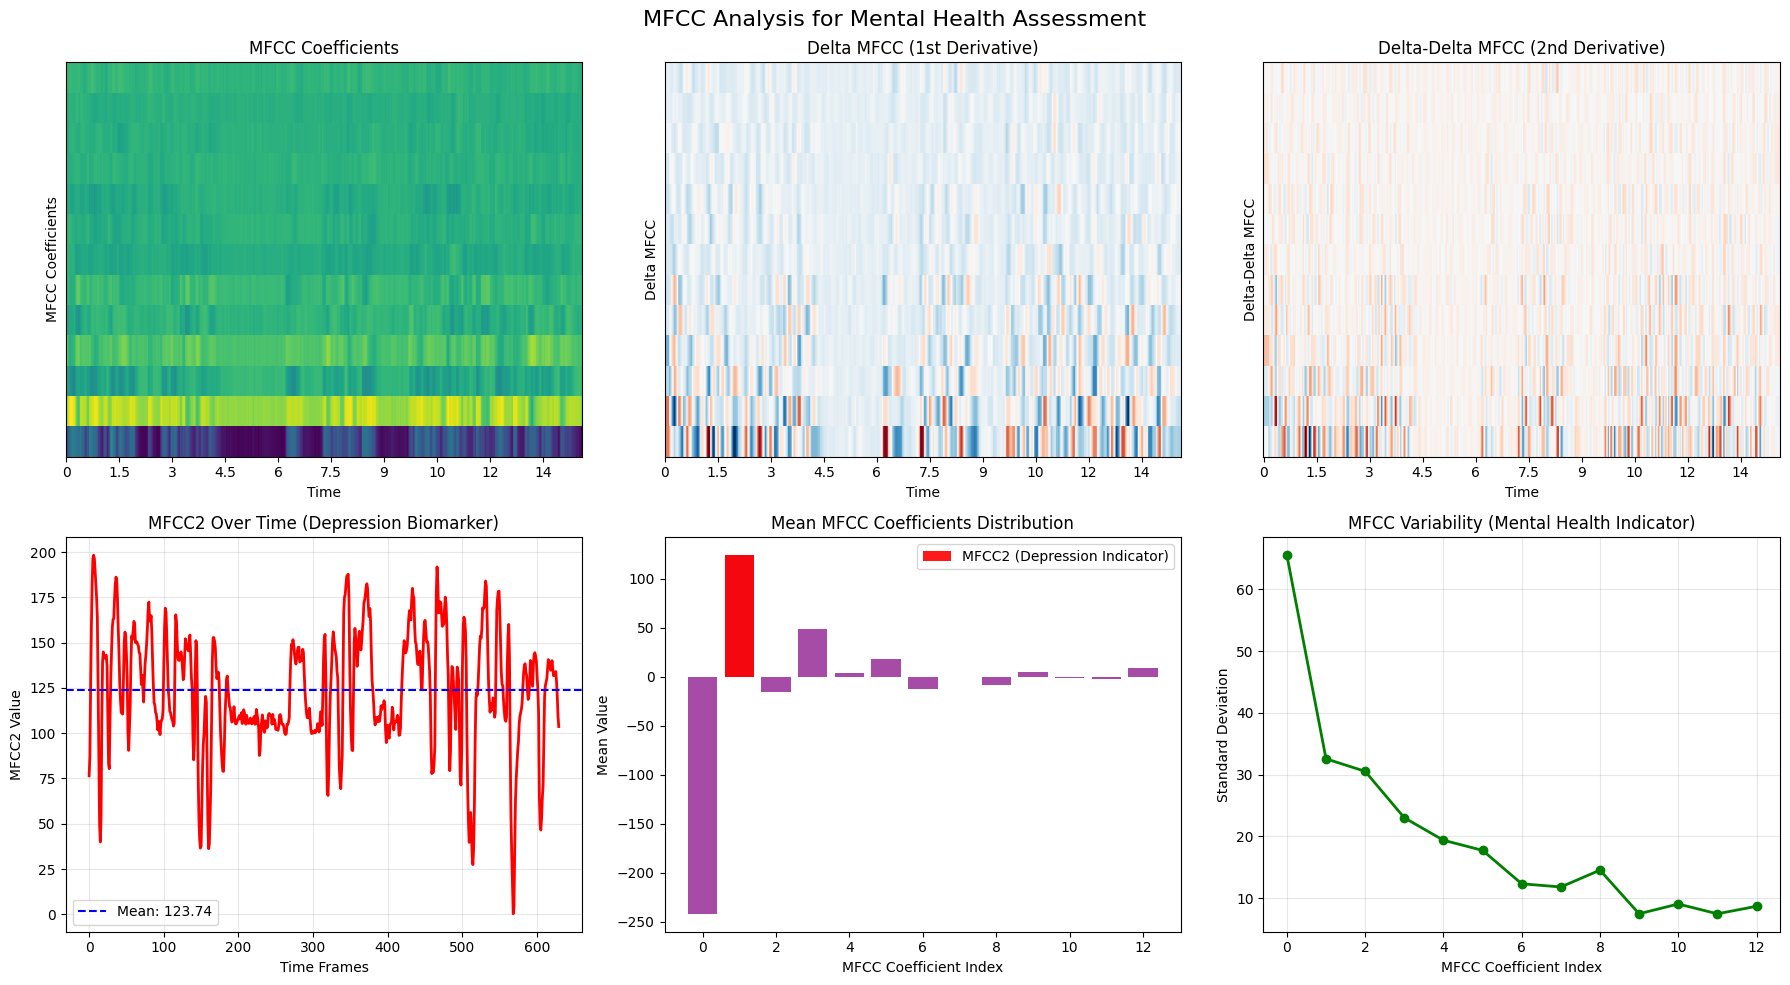

In [61]:
mfccs, delta_mfccs, delta2_mfccs = visualize_mfcc_mental_health(audio_file)

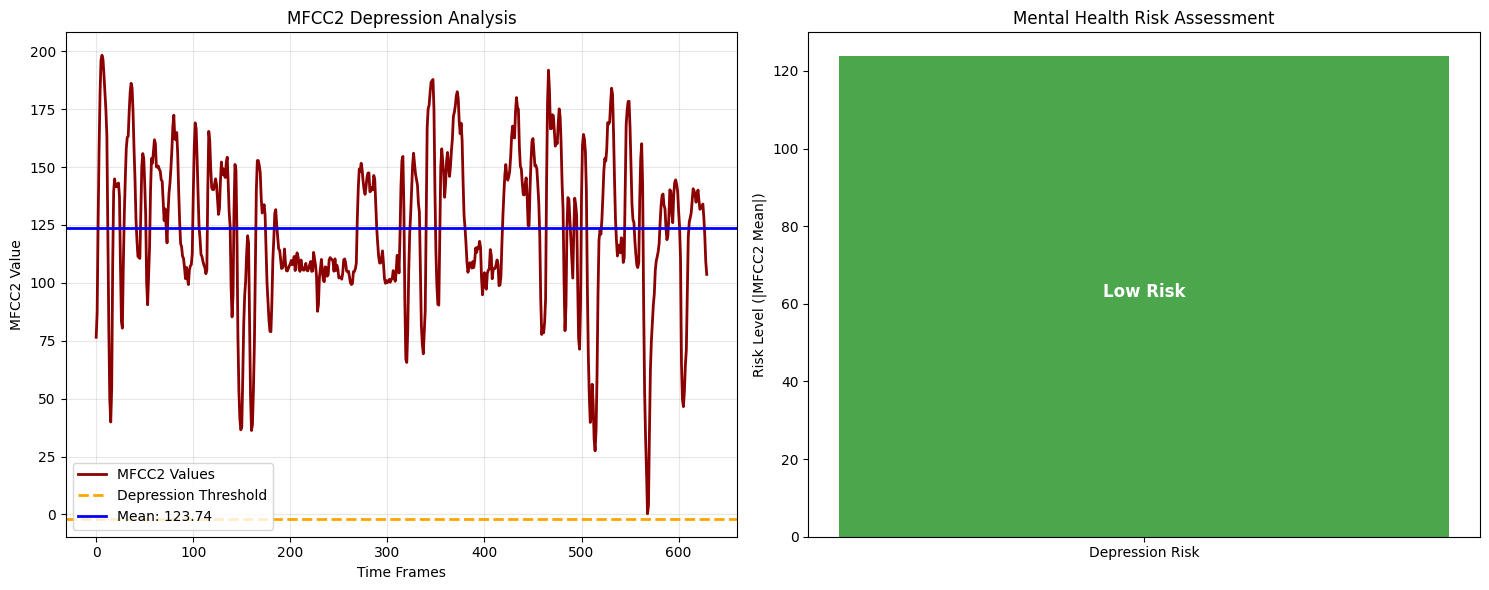


=== Mental Health MFCC Analysis ===
MFCC2 Mean Value: 123.740
Overall MFCC Variability: 15.239
Depression Risk Indicator: LOW
Interpretation: Normal spectral energy distribution


In [62]:
mfcc2_mean, variability, risk = mental_health_mfcc_analysis(audio_file)

In [14]:
import librosa
import numpy as np
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

class MFCCMentalHealthAnalyzer:
    """
    Comprehensive MFCC feature extraction class for mental health analysis.
    All methods return scalar values or strings for DataFrame storage.
    """
    
    def __init__(self, sr=22050, n_mfcc=13, n_fft=2048, hop_length=512):
        self.sr = sr
        self.n_mfcc = n_mfcc
        self.n_fft = n_fft
        self.hop_length = hop_length
    
    def extract_all_features(self, audio_path):
        """
        Extract all MFCC-based mental health features from audio file.
        
        Returns:
        dict: Dictionary containing all scalar/string features
        """
        try:
            # Load audio
            y, sr = librosa.load(audio_path, sr=self.sr)
            
            # Extract MFCC features
            mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=self.n_mfcc, 
                                       n_fft=self.n_fft, hop_length=self.hop_length)
            
            # Extract delta features
            delta_mfccs = librosa.feature.delta(mfccs)
            delta2_mfccs = librosa.feature.delta(mfccs, order=2)
            
            # Calculate all features
            features = {
                # Core MFCC features
                'mfcc2_mean': self.get_mfcc2_mean(mfccs),
                'mfcc_overall_variability': self.get_overall_variability(mfccs),
                'depression_risk_indicator': self.get_depression_risk_indicator(mfccs),
                
                # Additional important features
                'mfcc_spectral_centroid': self.get_mfcc_spectral_centroid(mfccs, sr),
                'mfcc_energy_concentration': self.get_energy_concentration(mfccs),
                'mfcc_dynamic_range': self.get_dynamic_range(mfccs),
                'mfcc_coefficient_stability': self.get_coefficient_stability(mfccs),
                'mfcc_first_formant_estimate': self.get_first_formant_estimate(mfccs, sr),
                
                # Delta-based features
                'delta_mfcc_variability': self.get_delta_variability(delta_mfccs),
                'delta2_mfcc_energy': self.get_delta2_energy(delta2_mfccs),
                
                # Advanced features
                'mfcc_entropy': self.get_mfcc_entropy(mfccs),
                'mfcc_kurtosis': self.get_mfcc_kurtosis(mfccs),
                'mfcc_zero_crossing_analog': self.get_zero_crossing_analog(mfccs),
                'mfcc_spectral_rolloff_estimate': self.get_spectral_rolloff_estimate(mfccs),
                'mfcc_bandwidth_estimate': self.get_bandwidth_estimate(mfccs),
                
                # Clinical interpretation
                'mental_health_risk_level': self.get_mental_health_risk_level(mfccs),
                'speech_monotony_indicator': self.get_speech_monotony_indicator(mfccs),
                'vocal_tract_stability': self.get_vocal_tract_stability(mfccs)
            }
            
            return features
            
        except Exception as e:
            print(f"Error in MFCC feature extraction: {str(e)}")
            return self._get_default_features()
    
    def get_mfcc2_mean(self, mfccs):
        """
        Calculate MFCC2 mean value - critical for depression detection.
        Lower values (< -2.0) often indicate depression.
        """
        return float(np.mean(mfccs[1, :]))  # MFCC2 is index 1
    
    def get_overall_variability(self, mfccs):
        """
        Calculate overall MFCC variability across all coefficients.
        Lower values indicate more monotone speech patterns.
        """
        return float(np.mean(np.std(mfccs, axis=1)))
    
    def get_depression_risk_indicator(self, mfccs):
        """
        Depression risk indicator based on MFCC2 threshold analysis.
        Returns: 'HIGH', 'MODERATE', or 'LOW'
        """
        mfcc2_mean = np.mean(mfccs[1, :])
        
        if mfcc2_mean < -2.5:
            return 'HIGH'
        elif mfcc2_mean < -1.5:
            return 'MODERATE'
        else:
            return 'LOW'
    
    def get_mfcc_spectral_centroid(self, mfccs, sr):
        """
        Estimate spectral centroid from MFCC coefficients.
        Lower values indicate flatter, more monotone speech.
        """
        # Approximate spectral centroid from MFCC distribution
        freq_weights = np.arange(len(mfccs)) * (sr / 2) / len(mfccs)
        mean_coeffs = np.mean(np.abs(mfccs), axis=1)
        
        if np.sum(mean_coeffs) > 0:
            centroid = np.sum(freq_weights * mean_coeffs) / np.sum(mean_coeffs)
            return float(centroid)
        else:
            return 0.0
    
    def get_energy_concentration(self, mfccs):
        """
        Calculate energy concentration in lower frequency bands.
        Higher values indicate more energy in lower frequencies (depression marker).
        """
        lower_band_energy = np.mean(np.abs(mfccs[:4, :]))  # First 4 coefficients
        total_energy = np.mean(np.abs(mfccs))
        
        if total_energy > 0:
            return float(lower_band_energy / total_energy)
        else:
            return 0.0
    
    def get_dynamic_range(self, mfccs):
        """
        Calculate dynamic range of MFCC coefficients.
        Lower values indicate less dynamic speech.
        """
        return float(np.max(mfccs) - np.min(mfccs))
    
    def get_coefficient_stability(self, mfccs):
        """
        Measure how stable the MFCC coefficients are over time.
        Higher values indicate more stable (potentially monotone) speech.
        """
        temporal_stability = []
        for i in range(len(mfccs)):
            coeff_var = np.var(mfccs[i, :])
            temporal_stability.append(coeff_var)
        
        # Return inverse of mean variance (higher = more stable)
        mean_variance = np.mean(temporal_stability)
        if mean_variance > 0:
            return float(1.0 / (1.0 + mean_variance))
        else:
            return 1.0
    
    def get_first_formant_estimate(self, mfccs, sr):
        """
        Estimate first formant frequency from MFCC coefficients.
        Abnormal values may indicate altered vocal tract configuration.
        """
        # Rough approximation of F1 from MFCC2 and MFCC3
        mfcc2_mean = np.mean(mfccs[1, :])
        mfcc3_mean = np.mean(mfccs[2, :])
        
        # Empirical formula for F1 estimation
        f1_estimate = 600 + (mfcc2_mean * 100) + (mfcc3_mean * 50)
        return float(max(200, min(1000, f1_estimate)))  # Clamp to reasonable range
    
    def get_delta_variability(self, delta_mfccs):
        """
        Calculate variability in delta MFCC coefficients.
        Lower values indicate less dynamic speech changes.
        """
        return float(np.mean(np.std(delta_mfccs, axis=1)))
    
    def get_delta2_energy(self, delta2_mfccs):
        """
        Calculate energy in delta-delta coefficients.
        Lower values indicate less acceleration in speech changes.
        """
        return float(np.mean(np.abs(delta2_mfccs)))
    
    def get_mfcc_entropy(self, mfccs):
        """
        Calculate entropy of MFCC coefficient distribution.
        Lower values indicate less information content (monotone speech).
        """
        # Normalize coefficients to probability distribution
        abs_coeffs = np.abs(mfccs.flatten())
        abs_coeffs = abs_coeffs / np.sum(abs_coeffs) if np.sum(abs_coeffs) > 0 else abs_coeffs
        
        # Calculate entropy
        entropy = -np.sum(abs_coeffs * np.log2(abs_coeffs + 1e-10))
        return float(entropy)
    
    def get_mfcc_kurtosis(self, mfccs):
        """
        Calculate kurtosis of MFCC coefficients.
        Higher values indicate more peaked distributions (less variability).
        """
        flattened = mfccs.flatten()
        return float(stats.kurtosis(flattened))
    
    def get_zero_crossing_analog(self, mfccs):
        """
        MFCC analog of zero-crossing rate.
        Count sign changes in MFCC coefficients over time.
        """
        sign_changes = 0
        total_comparisons = 0
        
        for i in range(len(mfccs)):
            coeff_series = mfccs[i, :]
            for j in range(len(coeff_series) - 1):
                if coeff_series[j] * coeff_series[j + 1] < 0:
                    sign_changes += 1
                total_comparisons += 1
        
        return float(sign_changes / total_comparisons) if total_comparisons > 0 else 0.0
    
    def get_spectral_rolloff_estimate(self, mfccs):
        """
        Estimate spectral rolloff frequency from MFCC distribution.
        Lower values indicate more energy in lower frequencies.
        """
        # Find coefficient index where 85% of energy is contained
        abs_coeffs = np.mean(np.abs(mfccs), axis=1)
        cumulative_energy = np.cumsum(abs_coeffs)
        total_energy = cumulative_energy[-1]
        
        if total_energy > 0:
            rolloff_idx = np.where(cumulative_energy >= 0.85 * total_energy)[0]
            if len(rolloff_idx) > 0:
                return float(rolloff_idx[0] / len(mfccs))
        
        return 0.85  # Default rolloff ratio
    
    def get_bandwidth_estimate(self, mfccs):
        """
        Estimate spectral bandwidth from MFCC coefficient spread.
        Lower values indicate narrower frequency content.
        """
        mean_coeffs = np.mean(np.abs(mfccs), axis=1)
        
        # Calculate weighted standard deviation
        weights = np.arange(len(mean_coeffs))
        if np.sum(mean_coeffs) > 0:
            weighted_mean = np.sum(weights * mean_coeffs) / np.sum(mean_coeffs)
            weighted_var = np.sum(mean_coeffs * (weights - weighted_mean) ** 2) / np.sum(mean_coeffs)
            return float(np.sqrt(weighted_var))
        else:
            return 0.0
    
    def get_mental_health_risk_level(self, mfccs):
        """
        Overall mental health risk assessment based on multiple MFCC indicators.
        Returns: 'HIGH', 'MODERATE', or 'LOW'
        """
        # Multiple risk factors
        mfcc2_mean = np.mean(mfccs[1, :])
        variability = np.mean(np.std(mfccs, axis=1))
        energy_concentration = self.get_energy_concentration(mfccs)
        
        risk_score = 0
        
        # MFCC2 factor
        if mfcc2_mean < -2.5:
            risk_score += 2
        elif mfcc2_mean < -1.5:
            risk_score += 1
        
        # Variability factor
        if variability < 0.3:
            risk_score += 2
        elif variability < 0.5:
            risk_score += 1
        
        # Energy concentration factor
        if energy_concentration > 0.7:
            risk_score += 1
        
        if risk_score >= 4:
            return 'HIGH'
        elif risk_score >= 2:
            return 'MODERATE'
        else:
            return 'LOW'
    
    def get_speech_monotony_indicator(self, mfccs):
        """
        Indicator of speech monotony based on coefficient variation.
        Returns: 'HIGH', 'MODERATE', or 'LOW'
        """
        variability = np.mean(np.std(mfccs, axis=1))
        
        if variability < 0.3:
            return 'HIGH'
        elif variability < 0.6:
            return 'MODERATE'
        else:
            return 'LOW'
    
    def get_vocal_tract_stability(self, mfccs):
        """
        Assessment of vocal tract configuration stability.
        Returns: 'STABLE', 'MODERATE', or 'VARIABLE'
        """
        stability = self.get_coefficient_stability(mfccs)
        
        if stability > 0.8:
            return 'STABLE'
        elif stability > 0.6:
            return 'MODERATE'
        else:
            return 'VARIABLE'
    
    def _get_default_features(self):
        """Return default feature values in case of error."""
        return {
            'mfcc2_mean': 0.0,
            'mfcc_overall_variability': 0.0,
            'depression_risk_indicator': 'UNKNOWN',
            'mfcc_spectral_centroid': 0.0,
            'mfcc_energy_concentration': 0.0,
            'mfcc_dynamic_range': 0.0,
            'mfcc_coefficient_stability': 0.0,
            'mfcc_first_formant_estimate': 0.0,
            'delta_mfcc_variability': 0.0,
            'delta2_mfcc_energy': 0.0,
            'mfcc_entropy': 0.0,
            'mfcc_kurtosis': 0.0,
            'mfcc_zero_crossing_analog': 0.0,
            'mfcc_spectral_rolloff_estimate': 0.0,
            'mfcc_bandwidth_estimate': 0.0,
            'mental_health_risk_level': 'UNKNOWN',
            'speech_monotony_indicator': 'UNKNOWN',
            'vocal_tract_stability': 'UNKNOWN'
        }


In [ ]:
# Usage example for DataFrame integration:
def process_audio_dataframe(df, file_column='fil_id'):
    """
    Process entire DataFrame with MFCC features.
    
    Parameters:
    df: DataFrame with audio file paths
    file_column: Column name containing audio file paths
    
    Returns:
    DataFrame with added MFCC feature columns
    """
    analyzer = MFCCMentalHealthAnalyzer()
    
    # Initialize all feature columns
    default_features = analyzer._get_default_features()
    for feature_name in default_features.keys():
        df[f'mfcc_{feature_name}'] = default_features[feature_name]
    
    # Process each audio file
    for idx, row in df.iterrows():
        audio_path = row[file_column]
        features = analyzer.extract_all_features(audio_path)
        
        # Update DataFrame with extracted features
        for feature_name, feature_value in features.items():
            df.at[idx, f'mfcc_{feature_name}'] = feature_value
    
    return df

### Key Features Explained

1. Core Depression Indicators
- MFCC2 Mean: Critical biomarker for depression detection
- Overall Variability: Measures speech monotony (lower = more monotone)
- Depression Risk Indicator: Categorical assessment based on MFCC2 thresholds

2. Advanced Clinical Features
- Spectral Centroid: Frequency distribution center (lower = flatter affect)
- Energy Concentration: Lower frequency energy ratio (depression marker)
- Dynamic Range: Speech expressiveness measure
- First Formant Estimate: Vocal tract configuration indicator

3. Temporal Dynamics
- Delta Variability: Speech change patterns over time
-Delta-Delta Energy: Acceleration of speech changes
- Coefficient Stability: Vocal tract configuration consistency

4. Information Content
- MFCC Entropy: Information richness of speech
- Kurtosis: Distribution shape of coefficients
- Zero-Crossing Analog: MFCC-based variability measure

All features return scalar values (floats) or categorical strings suitable for DataFrame storage, making them perfect for your machine learning pipeline and statistical analysis.

# CPP

In [45]:
def cpp_tool(audio_path: str, max_quefrency: float = 0.01) -> float:
    """Cepstral Peak Prominence estimation tool"""
    try:
        y, sr = librosa.load(audio_path, sr=None)
        spectrum = np.abs(fft.fft(y))
        log_spectrum = np.log(spectrum + 1e-10)
        cepstrum = np.real(fft.ifft(log_spectrum))
        
        # Find peak in quefrency range corresponding to F0 (typically 60-400Hz)
        quefrencies = np.arange(len(cepstrum))/sr
        valid = (quefrencies > 1/400) & (quefrencies < 1/60)
        cpp = np.max(cepstrum[valid]) - np.median(cepstrum[valid])
        return float(cpp)
    except Exception as e:
        print(f"CPP Error: {e}")
        return 0.0

In [46]:
cpp_tool(audio_file)

0.05088530108332634

# LPC (Linear Predictive Coding)
### LPC models the vocal tract as a filter

In [36]:
def lpc_tool(audio_path: str, order: int = 12, frame_length: int = 2048, hop_length: int = 512):
    """Robust LPC coefficient extraction with proper array handling"""
    
    def levinson_durbin(r, order):
        """Levinson-Durbin recursion implementation"""
        a = np.zeros(order + 1)
        a[0] = 1.0
        e = r[0]        
        for k in range(1, order + 1):
            lam = -np.sum(a[:k] * r[1:k+1][::-1]) / e
            a_new = a.copy()
            a_new[1:k+1] += lam * a[k-1::-1]
            a = a_new
            a[k] = lam
            e *= (1 - lam**2)
        return a[1:], e

   
    try:
        # Load audio with librosa for better handling
        y, sr = librosa.load(audio_path, sr=None)
        y = librosa.util.normalize(y)  # Peak normalization
        
        # Framing with librosa
        frames = librosa.util.frame(y, frame_length=frame_length, hop_length=hop_length)
        
        lpc_coeffs = []
        for frame in frames.T:
            frame = frame - np.mean(frame)  # Remove DC offset
            
            # Autocorrelation with proper handling
            autocorr = np.correlate(frame, frame, mode='full')
            autocorr = autocorr[len(autocorr)//2:][:order+1]  # Take first order+1 coefficients
            
            if np.sum(np.abs(autocorr)) < 1e-6:
                lpc_coeffs.append(np.zeros(order))
                continue
                
            # Levinson-Durbin recursion
            a, _ = levinson_durbin(autocorr, order)
            lpc_coeffs.append(a)

        return np.array(lpc_coeffs)
    
    except Exception as e:
        print(f"LPC Error: {str(e)}")
        return np.array([])

In [37]:
lpc_coeff = lpc_tool(audio_file)
print(f"LPC coefficients shape: {lpc_coeff.shape}")

LPC coefficients shape: (453, 12)


In [38]:
# code to visualize the LPC

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

def visualize_lpc_depression(lpc_coeffs, frame_rate=100, variability_threshold=0.15):
    """
    Visualizes LPC coefficients with depression analysis features.
    
    Parameters:
    - lpc_coeffs (np.ndarray): 2D array of LPC coefficients (frames x order)
    - frame_rate (int): Frames per second for time axis
    - variability_threshold (float): Threshold for low variability warning (0-1)
    """
    num_frames, order = lpc_coeffs.shape
    time_axis = np.arange(num_frames) / frame_rate

    # Create custom colormap for coefficient gradients
    colors = LinearSegmentedColormap.from_list('depression_cmap', ['#2E86AB', '#A23B72'])

    plt.figure(figsize=(14, 7))
    
    # Plot individual coefficients with gradient coloring
    for i in range(order):
        plt.plot(time_axis, lpc_coeffs[:, i], 
                 color=colors(i/order), 
                 alpha=0.6,
                 label=f'LPC-{i+1}' if i < 5 else None)

    # Calculate and plot statistical features
    mean_coeffs = np.mean(lpc_coeffs, axis=0)
    std_coeffs = np.std(lpc_coeffs, axis=0)
    
    # Highlight low variability regions (potential depression marker)
    variability = np.std(lpc_coeffs, axis=1)
    low_var_regions = variability < (variability_threshold * np.max(variability))
    plt.fill_between(time_axis, 0, 1, where=low_var_regions,
                     color='red', alpha=0.1, transform=plt.gca().get_xaxis_transform(),
                     label='Low Variability Regions')

    # Add reference lines and annotations
    plt.axhline(np.mean(mean_coeffs), color='#333333', linestyle='--', 
                label='Global Mean')
    plt.text(0.05, 0.95, f'Avg Variability: {np.mean(variability):.2f}',
             transform=plt.gca().transAxes, fontsize=10,
             bbox=dict(facecolor='white', alpha=0.8))

    plt.title('LPC Coefficients Analysis - Depression Indicators', pad=20)
    plt.xlabel('Time (seconds)', fontsize=12)
    plt.ylabel('Coefficient Value', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend(loc='upper right', ncol=2)
    plt.tight_layout()
    plt.show()

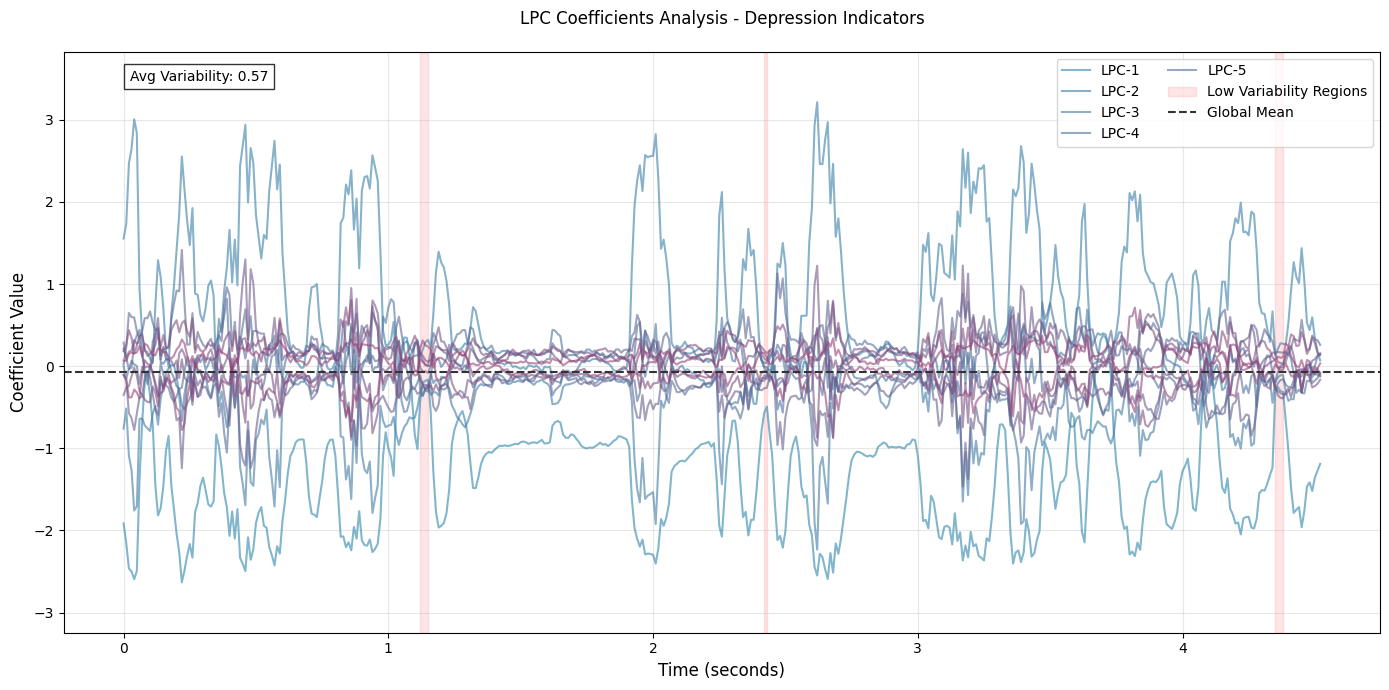

In [39]:
visualize_lpc_depression(lpc_coeff, frame_rate=100)

In [11]:
import numpy as np
import librosa

class LPCAnalyzer:
    def __init__(self, order=12, frame_length=2048, hop_length=512, sr=16000):
        self.order = order
        self.frame_length = frame_length
        self.hop_length = hop_length
        self.sr = sr

    def _levinson_durbin(self, r):
        """Levinson-Durbin recursion"""
        a = np.zeros(self.order + 1)
        a[0] = 1.0
        e = r[0]
        for k in range(1, self.order + 1):
            lam = -np.sum(a[:k] * r[1:k+1][::-1]) / e
            a_new = a.copy()
            a_new[1:k+1] += lam * a[k-1::-1]
            a = a_new
            a[k] = lam
            e *= (1 - lam**2)
        return a[1:], e

    def extract_lpc(self, audio_path):
        """Extract LPC coefficients"""
        try:
            y, sr = librosa.load(audio_path, sr=None)
            y = librosa.util.normalize(y)
            frames = librosa.util.frame(y, frame_length=self.frame_length, hop_length=self.hop_length)

            lpc_coeffs = []
            for frame in frames.T:
                frame = frame.copy()
                frame -= np.mean(frame)
                autocorr = np.correlate(frame, frame, mode='full')
                autocorr = autocorr[len(autocorr)//2:][:self.order+1]
                if np.sum(np.abs(autocorr)) < 1e-6:
                    lpc_coeffs.append(np.zeros(self.order))
                    continue
                a, _ = self._levinson_durbin(autocorr)
                lpc_coeffs.append(a)

            return np.array(lpc_coeffs)

        except Exception as e:
            print(f"LPC Error ({audio_path}): {str(e)}")
            return np.array([])

    def prediction_error_power(self, lpc_coeffs, audio_path):
        """Calculate prediction error power - indicates vocal tract modeling accuracy
        Higher values may indicate less predictable speech patterns, often associated with depression"""
        y, _ = librosa.load(audio_path, sr=None)
        frames = librosa.util.frame(y, frame_length=self.frame_length, hop_length=self.hop_length)

        total_error_power = 0
        for i, frame in enumerate(frames.T):
            if i < len(lpc_coeffs):
                predicted = np.convolve(frame, lpc_coeffs[i], mode='same')
                error = frame - predicted[:len(frame)]
                total_error_power += np.sum(error**2)

        return total_error_power / len(frames.T)

    def spectral_centroid(self, lpc_coeffs):
        """Calculate average spectral centroid from LPC coefficients
        Lower spectral centroids often correlate with flatter, more monotone speech patterns"""
        centroids = []
        freqs = np.fft.fftfreq(1024, 1 / self.sr)[:512]
        for coeffs in lpc_coeffs:
            h = np.abs(np.fft.fft(np.concatenate([[1], -coeffs]), 1024))[:512]
            centroid = np.sum(freqs * h) / np.sum(h)
            centroids.append(centroid)
        return np.mean(centroids)

    def stability_measure(self, lpc_coeffs):
        """Calculate average pole radius - measure of filter stability
         Values closer to 1.0 indicate less stable vocal tract configurations"""
        pole_radii = []
        for coeffs in lpc_coeffs:
            roots = np.roots(np.concatenate([[1], -coeffs]))
            pole_radii.extend(np.abs(roots))
        return np.mean(pole_radii)

    def first_formant_estimate(self, lpc_coeffs):
        """"Estimate first formant frequency from LPC analysis
        Altered formant patterns are associated with depression-related speech changes"""
        formants = []
        for coeffs in lpc_coeffs:
            roots = np.roots(np.concatenate([[1], -coeffs]))
            angles = np.angle(roots)
            freqs = angles * self.sr / (2 * np.pi)
            valid_freqs = freqs[(freqs > 200) & (freqs < 1000)]
            if len(valid_freqs) > 0:
                formants.append(np.min(valid_freqs))
        return np.mean(formants) if formants else 0

    def get_avg_variability(self, lpc_coeffs):
        """
        Calculate the average variability of LPC coefficients.
    
        Parameters:
        - lpc_coeffs (np.ndarray): 2D array (frames x order) of LPC coefficients
    
        Returns:
        - float: Average variability (mean of frame-wise standard deviations)
        """
        # Compute standard deviation across coefficients for each frame
        frame_variability = np.std(lpc_coeffs, axis=1)
        # Return the mean variability
        return np.mean(frame_variability)


In [13]:
lpc_analyzer = LPCAnalyzer()

audio_path = audio_file

lpc_coeffs = lpc_analyzer.extract_lpc(audio_path)
if lpc_coeffs.size > 0:
    error_power = lpc_analyzer.prediction_error_power(lpc_coeffs, audio_path)
    centroid = lpc_analyzer.spectral_centroid(lpc_coeffs)
    stability = lpc_analyzer.stability_measure(lpc_coeffs)
    formant = lpc_analyzer.first_formant_estimate(lpc_coeffs)
    varaibility = lpc_analyzer.get_avg_variability(lpc_coeffs)

    print("Error Power:", error_power)
    print("Spectral Centroid:", centroid)
    print("Stability Measure:", stability)
    print("First Formant Estimate:", formant)
    print("Avg Variability:", varaibility)


Error Power: 37.78684631446511
Spectral Centroid: 4072.4015414694404
Stability Measure: 0.8727913182341025
First Formant Estimate: 506.1282814142591
Avg Variability: 0.5748791434453766


# Data Text preprocessing

In [55]:
import pandas as pd
import torch
import os

In [8]:
df = pd.read_csv("/data/amey_2311cs10/debayan/audmind_structured_data/test_audmind.csv")

In [56]:
audio_id = os.path.basename(audio_file).replace('.wav', '')
# Now filter the DataFrame (assuming it has a column named 'file_id')
row = df[df['file_id'] == audio_id].iloc[0]
transcript = row['text']
question = row['Question']
answer = row['Answer']
reasoning = row['Reasoning']

### psychbert-finetuned-multiclass 

In [25]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Load directly from Hugging Face Hub
# tokenizer = AutoTokenizer.from_pretrained("mnaylor/psychbert-finetuned-multiclass")
# model = AutoModelForSequenceClassification.from_pretrained("mnaylor/psychbert-finetuned-multiclass")

model_name = "./psychbert-finetuned-multiclass"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

In [27]:
text = row["text"]
inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
outputs = model(**inputs)
logits = outputs.logits
predicted_class = logits.argmax(dim=1).item()

In [28]:
class_map = {
    0: "Negative / unrelated to mental health",
    1: "Mental illnesses",
    2: "Anxiety",
    3: "Depression",
    4: "Social anxiety",
    5: "Loneliness"
}
problem = class_map[predicted_class]
print("Detected problem:", problem)

Detected problem: Anxiety


### MentalLama chat 7B

In [11]:
from transformers import LlamaTokenizer, LlamaForCausalLM
import torch

class MentalHealthInference:
    def __init__(self):
        """Initialize the MentaLLaMA model for mental health analysis"""
        self.model_name = "klyang/MentaLLaMA-chat-7B"
        self.tokenizer = LlamaTokenizer.from_pretrained(self.model_name)
        self.model = LlamaForCausalLM.from_pretrained(
            self.model_name, 
            device_map="auto",
            torch_dtype=torch.float16
        )
    
    def analyze_mental_health(self, transcript, question=""):
        """
        Analyze mental health from transcript and optional question
        
        Args:
            transcript (str): Speech transcript or text input
            question (str): Optional specific question about mental health
            
        Returns:
            dict: Analysis results with assessment and explanation
        """
        # Construct prompt for mental health analysis
        if question:
            prompt = f"""<s>[INST] As a mental health professional, analyze the following transcript and answer the specific question. Provide your assessment and reasoning.

Transcript: {transcript}

Question: {question}

Please provide:
1. Mental health assessment
2. Key indicators observed
3. Confidence level in your assessment [/INST]"""
        else:
            prompt = f"""<s>[INST] As a mental health professional, analyze the following transcript for mental health indicators. Provide your assessment and reasoning.

Transcript: {transcript}

Please provide:
1. Mental health assessment
2. Key indicators observed  
3. Confidence level in your assessment [/INST]"""
        
        # Tokenize and generate response
        inputs = self.tokenizer(prompt, return_tensors="pt", truncation=True, max_length=2048)
        
        with torch.no_grad():
            outputs = self.model.generate(
                inputs.input_ids,
                max_new_tokens=512,
                temperature=0.7,
                do_sample=True,
                pad_token_id=self.tokenizer.eos_token_id
            )
        
        # Decode response
        response = self.tokenizer.decode(outputs[0], skip_special_tokens=True)
        analysis = response.split("[/INST]")[-1].strip()
        
        return {
            "model_used": "MentaLLaMA-chat-7B",
            "analysis": analysis,
            "transcript": transcript,
            "question": question if question else "General mental health assessment"
        }

# Usage example
def mental_health_inference(transcript, question=""):
    """Simple wrapper function for mental health inference"""
    analyzer = MentalHealthInference()
    return analyzer.analyze_mental_health(transcript, question)


/data/amey_2311cs10/anaconda3/envs/condapy312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
# Example 1: Basic transcript analysis
result = mental_health_inference(transcript)
print(result["analysis"])

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
/data/amey_2311cs10/anaconda3/envs/condapy312/lib/python3.12/site-packages/transformers/generation/utils.py:2347: UserWarning: You are calling .generate() with the `input_ids` being on a device type different than your model's device. `input_ids` is on cpu, whereas the model is on cuda. You may experience unexpected behaviors or slower generation. Please make sure that you have put `input_ids` to the correct device by calling for example input_ids = input_ids.to('cuda') before running `.generate()`.
  warnings.warn(


Mental Health Assessment:
Based on the provided transcript, there are no explicit mentions or descriptions of mental health symptoms or experiences commonly associated with mental disorders. The content primarily focuses on the speaker's discomfort and lack of enjoyment in taking tests, which is a specific issue related to academic performance rather than a mental health concern. Therefore, I would assign a label of "No mental health concerns" to this transcript.

Key Indicators Observed:
The transcript does not provide any indicators or symptoms related to mental health. The content primarily focuses on the speaker's experience with taking tests and their personal preferences.

Confidence Level in Assessment:
I would have a high level of confidence in my assessment as there are no clear indications or descriptions of mental health symptoms or experiences in the transcript. The content is primarily focused on a specific issue related to academic performance rather than mental health.


In [13]:
# Example 2: With specific question
result = mental_health_inference(transcript, question)
print(result["analysis"])

/data/amey_2311cs10/anaconda3/envs/condapy312/lib/python3.12/site-packages/transformers/generation/utils.py:2347: UserWarning: You are calling .generate() with the `input_ids` being on a device type different than your model's device. `input_ids` is on cpu, whereas the model is on cuda. You may experience unexpected behaviors or slower generation. Please make sure that you have put `input_ids` to the correct device by calling for example input_ids = input_ids.to('cuda') before running `.generate()`.
  warnings.warn(


Based on the given transcript, the patient shows no mental disorder symptoms. Reasoning: The transcript does not mention any symptoms or experiences commonly associated with mental disorders. It primarily focuses on the individual's past experience with testing and their current discomfort with taking tests. While the individual may have anxiety or discomfort related to testing, it does not necessarily indicate a mental disorder.


### MentalBERT

In [15]:
# this is a Gated model
from huggingface_hub import login
login(token="HF-TOKEN")

In [53]:
# from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
from transformers import AutoTokenizer, AutoModel

def mental_health_inference_fast(text, question=""):
    """
    Fast mental health analysis using MentalBERT
    
    Args:
        text (str): Input text (transcript or patient response)
        question (str): Optional context question
        
    Returns:
        dict: Analysis results with predictions and confidence
    """
    
    # Load MentalBERT model (much smaller and faster than MentaLLaMA)
    model_name = "mental/mental-bert-base-uncased"
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(model_name)
    
    # Combine text and question if provided
    input_text = f"{question} {text}" if question else text
    
    # Tokenize input
    inputs = tokenizer(
        input_text, 
        return_tensors="pt", 
        truncation=True, 
        max_length=512,
        padding=True
    )
    
    # Fast inference (no generation required)
    with torch.no_grad():
        outputs = model(**inputs)
        predictions = torch.nn.functional.softmax(outputs.logits, dim=-1)
        predicted_class = torch.argmax(predictions, dim=-1).item()
        confidence = torch.max(predictions).item()
    
    return {
        "model_used": "MentalBERT",
        "predicted_class": predicted_class,
        "confidence": confidence,
        "inference_type": "classification",
        "input_text": input_text
    }


In [54]:
# Usage example
result = mental_health_inference_fast(transcript)
print(f"Mental health assessment: {result}")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at mental/mental-bert-base-uncased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Mental health assessment: {'model_used': 'MentalBERT', 'predicted_class': 0, 'confidence': 0.5767512321472168, 'inference_type': 'classification', 'input_text': " All right, so in third grade you had a really bad testing experience.  and as you moved forward from there you've never really been thrilled about taking tests. No. But you've been able to"}


### mental-health-classification-v0.1

In [51]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

# Load the tokenizer and model
tokenizer = AutoTokenizer.from_pretrained("tahaenesaslanturk/mental-health-classification-v0.1")
model = AutoModelForSequenceClassification.from_pretrained("tahaenesaslanturk/mental-health-classification-v0.1")

# Encode the input text
input_text = transcript
inputs = tokenizer(input_text, return_tensors="pt")

# Perform inference
with torch.no_grad():
    outputs = model(**inputs)

# Get the predicted label
predicted_label = torch.argmax(outputs.logits, dim=1).item()
label = model.config.id2label[predicted_label]

print(f"Predicted label: {label}")


Predicted label: alcoholism


In [52]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

# Load the tokenizer and model
tokenizer = AutoTokenizer.from_pretrained("tahaenesaslanturk/mental-health-classification-v0.1")
model = AutoModelForSequenceClassification.from_pretrained("tahaenesaslanturk/mental-health-classification-v0.1")

# Input transcript
input_text = transcript  # Replace with actual string

# Tokenize
inputs = tokenizer(input_text, return_tensors="pt")

# Inference
with torch.no_grad():
    outputs = model(**inputs)

logits = outputs.logits.squeeze()  # shape: [num_labels]

# Get each label and its score
label_scores = []
for i, score in enumerate(logits):
    label_name = model.config.id2label[i]
    label_scores.append((label_name, score.item()))

# Print nicely
for label, score in label_scores:
    print(f"{label}: {score:.4f}")


EDAnonymous: -1.2868
addiction: -1.1467
alcoholism: 4.2556
adhd: -1.5236
anxiety: 2.6277
autism: -0.7256
bipolarreddit: -0.6644
bpd: -0.9307
depression: 2.5290
healthanxiety: -1.3494
lonely: -1.4266
ptsd: -1.8061
schizophrenia: -0.6277
socialanxiety: 0.5238
suicidewatch: -1.0456


## MentalBERT

In [1]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch.nn.functional as F

def load_mentalbert_model(device="cuda" if torch.cuda.is_available() else "cpu"):
    """
    Load MentalBERT model and tokenizer for inference
    """
    model_name = "mental/mental-bert-base-uncased"
    
    # Load tokenizer and model
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(model_name)
    model.to(device)
    model.eval()  # Set to evaluation mode
    
    return model, tokenizer, device

def classify_mental_health_text(text, model, tokenizer, device):
    """
    Perform mental health classification on input text using MentalBERT
    
    Args:
        text (str): Input text to classify
        model: Loaded MentalBERT model
        tokenizer: Loaded MentalBERT tokenizer
        device: Device to run inference on
    
    Returns:
        dict: Classification results with probabilities and predicted class
    """
    # Tokenize input text
    inputs = tokenizer(
        text, 
        return_tensors="pt", 
        truncation=True, 
        padding=True, 
        max_length=512
    ).to(device)
    
    # Perform inference
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        
        # Apply softmax to get probabilities
        probabilities = F.softmax(logits, dim=-1)
        
        # Get predicted class
        predicted_class = torch.argmax(probabilities, dim=-1).item()
        
        # Get confidence score
        confidence = torch.max(probabilities).item()
    
    # Prepare results
    results = {
        'predicted_class': predicted_class,
        'confidence': confidence,
        'probabilities': probabilities.cpu().numpy().flatten().tolist(),
        'raw_logits': logits.cpu().numpy().flatten().tolist()
    }
    
    return results

# Example usage function
def analyze_text_with_mentalbert(text):
    """
    Complete workflow to analyze text with MentalBERT
    """
    # Load model
    model, tokenizer, device = load_mentalbert_model()
    
    # Perform classification
    results = classify_mental_health_text(text, model, tokenizer, device)
    
    return results

# Usage example
if __name__ == "__main__":
    # sample_text = transcript
    sample_text = "I am very depressed, I am getting sick and tired of this work. I dont like anything and I can't sleep"
    results = analyze_text_with_mentalbert(sample_text)
    
    print("Classification Results:")
    print(f"Predicted Class: {results['predicted_class']}")
    print(f"Confidence: {results['confidence']:.4f}")
    print(f"Probabilities: {results['probabilities']}")


/data/amey_2311cs10/anaconda3/envs/condapy312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at mental/mental-bert-base-uncased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Classification Results:
Predicted Class: 1
Confidence: 0.5260
Probabilities: [0.47404199838638306, 0.5259580016136169]


### Bio_ClinicalBERT,  Twitter-RoBERTa
### Kevsum/mentalhealth_LM (Gives WRONG RESULT, so removed)

In [41]:
import torch
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    AutoModelForCausalLM, pipeline
)
import numpy as np
from typing import Dict, List, Any, Tuple, Optional
import logging

# Set up logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)



In [46]:
class MentalHealthClassifier:
    """Handles mental disorder classification using Bio_ClinicalBERT and Twitter-RoBERTa models"""
    
    def __init__(self, device: str = "cuda" if torch.cuda.is_available() else "cpu"):
        self.device = device
        self.clinical_model = None
        self.clinical_tokenizer = None
        self.sentiment_model = None
        self.sentiment_tokenizer = None
        
    def load_clinical_bert(self):
        """Load Bio_ClinicalBERT model for clinical text classification"""
        try:
            model_name = "emilyalsentzer/Bio_ClinicalBERT"
            self.clinical_tokenizer = AutoTokenizer.from_pretrained(model_name)
            self.clinical_model = AutoModelForSequenceClassification.from_pretrained(model_name)
            self.clinical_model.to(self.device)
            self.clinical_model.eval()
            logger.info(f"Clinical BERT model loaded successfully on {self.device}")
        except Exception as e:
            logger.error(f"Error loading Clinical BERT: {e}")
            raise
    
    def load_sentiment_roberta(self):
        """Load Twitter-RoBERTa model for sentiment analysis"""
        try:
            model_name = "cardiffnlp/twitter-roberta-base-sentiment-latest"
            self.sentiment_tokenizer = AutoTokenizer.from_pretrained(model_name)
            self.sentiment_model = AutoModelForSequenceClassification.from_pretrained(model_name)
            self.sentiment_model.to(self.device)
            self.sentiment_model.eval()
            logger.info(f"Sentiment RoBERTa model loaded successfully on {self.device}")
        except Exception as e:
            logger.error(f"Error loading Sentiment RoBERTa: {e}")
            raise
    
    def classify_clinical_text(self, text: str, max_length: int = 512) -> Dict[str, Any]:
        """
        Classify clinical text using Bio_ClinicalBERT
        
        Args:
            text: Input text to classify
            max_length: Maximum sequence length
            
        Returns:
            Dictionary containing predictions and confidence scores
        """
        if self.clinical_model is None:
            self.load_clinical_bert()
        
        try:
            # Tokenize input
            inputs = self.clinical_tokenizer(
                text,
                return_tensors="pt",
                max_length=max_length,
                truncation=True,
                padding=True
            ).to(self.device)
            
            # Get predictions
            with torch.no_grad():
                outputs = self.clinical_model(**inputs)
                predictions = torch.nn.functional.softmax(outputs.logits, dim=-1)
                
            # Convert to numpy for easier handling
            predictions_np = predictions.cpu().numpy()[0]
            predicted_class = np.argmax(predictions_np)
            confidence = float(predictions_np[predicted_class])
            
            return {
                "predicted_class": int(predicted_class),
                "confidence": confidence,
                "all_scores": predictions_np.tolist(),
                "model_used": "Bio_ClinicalBERT"
            }
            
        except Exception as e:
            logger.error(f"Error in clinical text classification: {e}")
            return {"error": str(e)}
    
    def analyze_sentiment(self, text: str, max_length: int = 512) -> Dict[str, Any]:
        """
        Analyze sentiment using Twitter-RoBERTa
        
        Args:
            text: Input text to analyze
            max_length: Maximum sequence length
            
        Returns:
            Dictionary containing sentiment analysis results
        """
        if self.sentiment_model is None:
            self.load_sentiment_roberta()
        
        try:
            # Tokenize input
            inputs = self.sentiment_tokenizer(
                text,
                return_tensors="pt",
                max_length=max_length,
                truncation=True,
                padding=True
            ).to(self.device)
            
            # Get predictions
            with torch.no_grad():
                outputs = self.sentiment_model(**inputs)
                predictions = torch.nn.functional.softmax(outputs.logits, dim=-1)
                
            # Convert to numpy
            predictions_np = predictions.cpu().numpy()[0]
            
            # Map to sentiment labels (typical for this model)
            sentiment_labels = ["negative", "neutral", "positive"]
            predicted_sentiment = sentiment_labels[np.argmax(predictions_np)]
            confidence = float(predictions_np[np.argmax(predictions_np)])
            
            return {
                "predicted_sentiment": predicted_sentiment,
                "confidence": confidence,
                "scores": {
                    label: float(score) 
                    for label, score in zip(sentiment_labels, predictions_np)
                },
                "model_used": "Twitter-RoBERTa"
            }
            
        except Exception as e:
            logger.error(f"Error in sentiment analysis: {e}")
            return {"error": str(e)}

In [42]:
def run_clinical_bert_classification(text: str, device: str = "auto") -> Dict[str, Any]:
    """
    Standalone function for Bio_ClinicalBERT classification
    
    Args:
        text: Input text to classify
        device: Device to run on ("auto", "cuda", "cpu")
        
    Returns:
        Classification results from Bio_ClinicalBERT
    """
    if device == "auto":
        device = "cuda" if torch.cuda.is_available() else "cpu"
    
    classifier = MentalHealthClassifier(device=device)
    result = classifier.classify_clinical_text(text)
    return result


In [43]:
def run_sentiment_roberta_analysis(text: str, device: str = "auto") -> Dict[str, Any]:
    """
    Standalone function for Twitter-RoBERTa sentiment analysis
    
    Args:
        text: Input text to analyze
        device: Device to run on ("auto", "cuda", "cpu")
        
    Returns:
        Sentiment analysis results from Twitter-RoBERTa
    """
    if device == "auto":
        device = "cuda" if torch.cuda.is_available() else "cpu"
    
    classifier = MentalHealthClassifier(device=device)
    result = classifier.analyze_sentiment(text)
    return result

In [47]:
def example_individual_usage(transcription,quest,ans):
    """Example of how to use each model function separately"""
    
    sample_text = transcription
    
    print("=== Bio_ClinicalBERT Classification ===")
    clinical_result = run_clinical_bert_classification(sample_text)
    print(f"Clinical Classification Result: {clinical_result}")
    print()
    
    print("=== Twitter-RoBERTa Sentiment Analysis ===")
    sentiment_result = run_sentiment_roberta_analysis(sample_text)
    print(f"Sentiment Analysis Result: {sentiment_result}")
    print()
    
    # print("=== KevSun/mentalhealth_LM Generation ===")
    # prompt = f"Analyze this patient statement: {sample_text}\nMental health assessment:"
    # generation_result = run_mental_health_generation(prompt)
    # print(f"Generation Result: {generation_result}")
    # print()
    
    # print("=== QA Explanation Generation ===")
    # qa_result = run_qa_explanation_generation(
    #     question=quest,
    #     answer=ans,
    #     context=sample_text
    # )
    # print(f"QA Explanation Result: {qa_result}")




In [48]:
if __name__ == "__main__":
    # Example usage of individual functions
    try:
        example_individual_usage(transcript, question, answer)
    except Exception as e:
        print(f"Error in example usage: {e}")

=== Bio_ClinicalBERT Classification ===


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at emilyalsentzer/Bio_ClinicalBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
INFO:__main__:Clinical BERT model loaded successfully on cuda


Clinical Classification Result: {'predicted_class': 0, 'confidence': 0.5613304972648621, 'all_scores': [0.5613304972648621, 0.43866947293281555], 'model_used': 'Bio_ClinicalBERT'}

=== Twitter-RoBERTa Sentiment Analysis ===


Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
INFO:__main__:Sentiment RoBERTa model loaded successfully on cuda


Sentiment Analysis Result: {'predicted_sentiment': 'negative', 'confidence': 0.690974235534668, 'scores': {'negative': 0.690974235534668, 'neutral': 0.2759135961532593, 'positive': 0.03311210870742798}, 'model_used': 'Twitter-RoBERTa'}



# Therapulse

In [ ]:
def use_therapulse_tool(audio_path=None, transcript=None, question=None):
    """
    Use the Therapulse tool on therapy session data.

    Args:
        audio_path (str): Path to the audio file (optional if transcript is given).
        transcript (str): Transcript text of the session.
        question (str): Question to ask (e.g., 'Does this person suffer from a mental disorder?').

    Returns:
        dict: {
            'answer': str,
            'reasoning': str
        }
    """
    
    # Step 1: Transcribe if only audio is provided
    if transcript is None and audio_path:
        transcript = transcribe_audio(audio_path)

    if not transcript or not question:
        raise ValueError("Transcript and question are required.")

    # Step 2: Format input for Therapulse
    input_data = {
        "transcript": transcript,
        "question": question
    }

    # Step 3: Call Therapulse (Placeholder: replace with actual call)
    result = therapulse_infer(input_data)

    return {
        "answer": result.get("answer", "Unknown"),
        "reasoning": result.get("reasoning", "No explanation provided.")
    }


# --- Placeholder functions you need to define or replace ---

def transcribe_audio(audio_path):
    # Replace with your transcription logic (e.g., Whisper, ASR, etc.)
    import whisper
    model = whisper.load_model("base")
    result = model.transcribe(audio_path)
    return result['text']

def therapulse_infer(input_data):
    """
    Dummy implementation — Replace with actual Therapulse call.
    Expected input_data:
        {
            "transcript": str,
            "question": str
        }
    Returns:
        {
            "answer": str,
            "reasoning": str
        }
    """
    # Example dummy output
    return {
        "answer": "Yes, the person shows signs of depression.",
        "reasoning": "The transcript reveals persistent feelings of sadness, hopelessness, and low self-worth over multiple exchanges."
    }


In [ ]:
def use_therapulse_tool(audio, transcript, question):
    """
    Uses the Therapulse tool to analyze therapy session data.

    Args:
        audio (str): Path to the audio file.
        transcript (str): Transcript text of the session.
        question (str): Analytical question (e.g., diagnostic).

    Returns:
        dict: A dictionary with 'answer' and 'reasoning'.
    """
    if not transcript or not question:
        raise ValueError("Both transcript and question are required.")

    input_data = {
        "audio_path": audio,
        "transcript": transcript,
        "question": question
    }

    # Step 1: Send to Therapulse model (replace this with real call)
    result = therapulse_infer(input_data)

    return {
        "answer": result.get("answer", "Unknown"),
        "reasoning": result.get("reasoning", "No explanation provided.")
    }


# --- Stub for Therapulse inference (replace this with actual model or API call) ---
def therapulse_infer(data):
    """
    Simulated Therapulse model call.

    Args:
        data (dict): Dictionary containing 'audio_path', 'transcript', and 'question'.

    Returns:
        dict: Dictionary with 'answer' and 'reasoning'.
    """
    transcript = data['transcript']
    question = data['question']

    # Dummy logic: just for illustration
    if "depression" in transcript.lower():
        answer = "Yes, the person may suffer from depression."
        reasoning = "The transcript mentions signs like persistent sadness and hopelessness."
    else:
        answer = "No clear signs of mental disorder."
        reasoning = "The transcript lacks consistent indicators of distress."

    return {"answer": answer, "reasoning": reasoning}


In [ ]:
# Example variables (replace these with your real data)
# audio = "./audio/session1.wav"
# transcript = "The patient says they feel tired all day and lack interest in things they used to enjoy."
# question = "Does this person suffer from a mental disorder?"

# Run Therapulse tool
result = use_therapulse_tool(audio_file, transcript, question)

# Output
print("Answer:", result["answer"])
print("Reasoning:", result["reasoning"])


### Emotion classification from text

### t5-base-finetuned-emotion

In [40]:
from transformers import AutoTokenizer, AutoModelWithLMHead

tokenizer = AutoTokenizer.from_pretrained("mrm8488/t5-base-finetuned-emotion")
model = AutoModelWithLMHead.from_pretrained("mrm8488/t5-base-finetuned-emotion")

def get_emotion(text):
  input_ids = tokenizer.encode(text + '</s>', return_tensors='pt')
  output = model.generate(input_ids=input_ids,max_length=2)  
  dec = [tokenizer.decode(ids) for ids in output]
  label = dec[0]
  return label
  
print(transcript, get_emotion(transcript), sep="\n")

 All right, so in third grade you had a really bad testing experience.  and as you moved forward from there you've never really been thrilled about taking tests. No. But you've been able to
<pad> joy


### bert-emotion

In [29]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer
model = AutoModelForSequenceClassification.from_pretrained("boltuix/bert-emotion")
tokenizer = AutoTokenizer.from_pretrained("boltuix/bert-emotion")

In [30]:
from transformers import pipeline

# Load the fine-tuned BERT-Emotion model
sentiment_analysis = pipeline("text-classification", model="boltuix/bert-emotion")

# Analyze emotion
result = sentiment_analysis(transcript)
print(result)

Device set to use cuda:0


[{'label': 'love', 'score': 0.2887478470802307}]


If the confidence is low, we dont need to trust the label

### Emotion classification from voice

In [22]:
import torch
import numpy as np
from transformers import Wav2Vec2Model
import torchaudio
from torchaudio.transforms import Resample

In [25]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
wav2vec2_model = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base", output_hidden_states=True).to(device)

class FineTunedWav2Vec2Model(torch.nn.Module):
    def __init__(self, wav2vec2_model, output_size):
        super(FineTunedWav2Vec2Model, self).__init__()
        self.wav2vec2 = wav2vec2_model
        self.fc = torch.nn.Linear(self.wav2vec2.config.hidden_size, output_size)

    def forward(self, x):
        self.wav2vec2 = self.wav2vec2.double()
        self.fc = self.fc.double()
        outputs = self.wav2vec2(x.double())
        out = outputs.hidden_states[-1]
        out = self.fc(out[:, 0, :])
        return out

def preprocess_audio(audio):
    sample_rate, waveform = audio
    if isinstance(waveform, np.ndarray):
        waveform = torch.from_numpy(waveform)
    if waveform.dim() == 2:
        waveform = waveform.mean(dim=0)
    
    # Normalize audio
    if waveform.dtype != torch.float32:
        waveform = waveform.float() / torch.iinfo(waveform.dtype).max
    
    # Resample to 16kHz
    if sample_rate != 16000:
        resampler = Resample(orig_freq=sample_rate, new_freq=16000)
        waveform = resampler(waveform)
    return waveform

def predict(audio):
    model_path = "/data/amey_2311cs10/debayan/tools-audmind/SpeechEmotionDetector/model.pth"  # Path to your fine-tuned model
    model = FineTunedWav2Vec2Model(wav2vec2_model, 7).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    waveform = preprocess_audio(audio)
    waveform = waveform.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(waveform)

    predicted_label = torch.argmax(output, dim=1).item()
    emotion_labels = ["Angry", "Disgust", "Fear", "Happy", "Neutral", "Sad", "Surprise"]
    return emotion_labels[predicted_label]

In [26]:
# Example usage
waveform, sample_rate = torchaudio.load(audio_file)  # waveform shape: [channels, samples]
audio_data = (sample_rate, waveform)
emotion = predict(audio_data)
print(f"Predicted Emotion: {emotion}")

Predicted Emotion: Angry
